In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split

import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
#now debugging is reproducible

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
PROP_DIM   = 2
N_POINTS   = 1024
POINT_DIM  = 3
PC_DIM     = N_POINTS * POINT_DIM
HIDDEN_DIM = 512
Z_DIM      = 64

BATCH_SIZE  = 8
EPOCHS      = 200
LR          = 1e-3

#SOMETHING CALLED KL ANNEALING
BETA_START  = 0.0
BETA_END    = 1.0
BETA_WARMUP = 50

VAL_SPLIT   = 0.15

In [3]:
class ParetoShapeDataset(Dataset):
    def __init__(self, properties, point_clouds):
        props = torch.tensor(properties, dtype=torch.float32)
        pcs = torch.tensor(point_clouds, dtype=torch.float32)

        self.prop_min = props.min(dim=0, keepdim=True)[0]
        self.prop_max = props.max(dim=0, keepdim=True)[0]
        self.props = (props - self.prop_min) / (self.prop_max - self.prop_min + 1e-8)

        centroids = pcs.mean(dim=1, keepdim=True)
        pcs = pcs - centroids
        max_norms = torch.norm(pcs, dim=2).max(dim=1, keepdim=True)[0].unsqueeze(2)
        self.pcs = pcs / (max_norms + 1e-8)

    def __len__(self):
        return len(self.props)

    def __getitem__(self, idx):
        return self.props[idx], self.pcs[idx]

stage1_data = torch.load("stage1_outputs/pareto_dataset.pt")
real_props = stage1_data["properties"]
real_pcs = stage1_data["point_clouds"]

dataset = ParetoShapeDataset(real_props, real_pcs)

n_val   = int(len(dataset) * VAL_SPLIT)
n_train = len(dataset) - n_val
train_set, val_set = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {n_train:,}  |  Val: {n_val:,} shapes")
print(f"Point cloud shape per sample: ({N_POINTS}, {POINT_DIM})")

Train: 43  |  Val: 7 shapes
Point cloud shape per sample: (1024, 3)


/tmp/ipykernel_7553/167598073.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  props = torch.tensor(properties, dtype=torch.float32)
/tmp/ipykernel_7553/167598073.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pcs = torch.tensor(point_clouds, dtype=torch.float32)


In [4]:
class PropertyPredictor(nn.Module):
    def __init__(self, pc_dim, prop_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(pc_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, prop_dim)
        )

    def forward(self, point_cloud):
        pc_flat = point_cloud.view(point_cloud.size(0), -1)
        return self.net(pc_flat)

In [5]:
class Encoder(nn.Module):
    def __init__(self, prop_dim, pc_dim, hidden_dim, z_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(prop_dim + pc_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim,        hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)

    def forward(self, properties, point_cloud):
        # point_cloud: (B, N_POINTS, 3) -> flatten to (B, N_POINTS*3)
        pc_flat = point_cloud.view(point_cloud.size(0), -1)
        h = self.net(torch.cat([properties, pc_flat], dim=-1))
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):

    def __init__(self, z_dim, prop_dim, hidden_dim, pc_dim, n_points, point_dim=3):
        super().__init__()
        self.n_points  = n_points
        self.point_dim = point_dim
        self.net = nn.Sequential(
            nn.Linear(z_dim + prop_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim,       hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim,       pc_dim),     # output: flattened point cloud
        )

    def forward(self, z, properties):
        out = self.net(torch.cat([z, properties], dim=-1))          # (B, N_POINTS*3)
        return out.view(out.size(0), self.n_points, self.point_dim) # (B, N_POINTS, 3)


class CVAE(nn.Module):
    def __init__(self, prop_dim, n_points, point_dim=3, hidden_dim=512, z_dim=128):
        super().__init__()
        pc_dim = n_points * point_dim
        self.encoder = Encoder(prop_dim, pc_dim, hidden_dim, z_dim)
        self.decoder = Decoder(z_dim, prop_dim, hidden_dim, pc_dim, n_points, point_dim)
        self.z_dim   = z_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, properties, point_cloud):
        mu, logvar = self.encoder(properties, point_cloud)
        z          = self.reparameterize(mu, logvar)
        p_hat      = self.decoder(z, properties)
        return p_hat, mu, logvar

    @torch.no_grad()
    def generate(self, properties, n_samples=1):
        self.eval()
        if properties.dim() == 1:
            properties = properties.unsqueeze(0).expand(n_samples, -1)
        z = torch.randn(n_samples, self.z_dim, device=properties.device)
        return self.decoder(z, properties)


model = CVAE(PROP_DIM, N_POINTS, POINT_DIM, HIDDEN_DIM, Z_DIM).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

CVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=3074, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (5): ReLU()
    )
    (fc_mu): Linear(in_features=512, out_features=64, bias=True)
    (fc_logvar): Linear(in_features=512, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=66, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (5): ReLU()
      (6): Linear(in_features=512, out_features=3072, bias=True)
    )
  )
)

Trainable parameters: 3,779,712


In [6]:
def chamfer_distance(pc1, pc2):
    diff = pc1.unsqueeze(2) - pc2.unsqueeze(1)
    dist = (diff ** 2).sum(-1)                       # (B, N, M)
    loss = dist.min(dim=2).values.mean() + dist.min(dim=1).values.mean()
    return loss


def cvae_loss(p_hat, p, mu, logvar, beta=1.0, free_bits=0.1, use_chamfer=True):
    if use_chamfer:
        recon_loss = chamfer_distance(p_hat, p)
    else:
        recon_loss = F.mse_loss(p_hat, p, reduction='mean')

    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl_per_dim = torch.clamp(kl_per_dim, min=free_bits)
    kl_loss = kl_per_dim.sum(dim=1).mean()

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

def get_beta(epoch):
    if epoch >= BETA_WARMUP:
        return BETA_END
    return BETA_START + (BETA_END - BETA_START) * (epoch / BETA_WARMUP)

## 6. Training Loop

In [7]:
predictor = PropertyPredictor(PC_DIM, PROP_DIM, HIDDEN_DIM).to(DEVICE)

optimizer = torch.optim.Adam(list(model.parameters()) + list(predictor.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)
LAMBDA_PROP = 0.1
FREE_BITS = 0.1

history = {"train_loss": [], "train_recon": [], "train_kl": [], "train_prop": [],
           "val_loss":   [], "val_recon":   [], "val_kl":   [], "val_prop":   []}

def run_epoch(loader, train=True, beta=1.0):
    model.train(train)
    predictor.train(train)
    totals = {"loss": 0.0, "recon": 0.0, "kl": 0.0, "prop": 0.0}
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for props, pcs in loader:
            props = props.to(DEVICE)
            pcs = pcs.to(DEVICE)

            p_hat, mu, logvar = model(props, pcs)
            loss_cvae, recon, kl = cvae_loss(p_hat, pcs, mu, logvar, beta, free_bits=FREE_BITS)

            q_hat = predictor(p_hat)
            loss_prop = F.mse_loss(q_hat, props)

            loss = loss_cvae + LAMBDA_PROP * loss_prop

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                nn.utils.clip_grad_norm_(predictor.parameters(), max_norm=1.0)
                optimizer.step()

            totals["loss"]  += loss.item()
            totals["recon"] += recon.item()
            totals["kl"]    += kl.item()
            totals["prop"]  += loss_prop.item()

    n = len(loader)
    return {k: v / n for k, v in totals.items()}

print(f"{'Epoch':>6} | {'Beta':>5} | {'Train Loss':>11} | {'Recon':>9} | {'KL':>9} | {'Prop':>9} | {'Val Loss':>9}")
print("-" * 75)

for epoch in range(EPOCHS):
    beta        = get_beta(epoch)
    train_stats = run_epoch(train_loader, train=True,  beta=beta)
    val_stats   = run_epoch(val_loader,   train=False, beta=beta)
    scheduler.step()

    for split, stats in [("train", train_stats), ("val", val_stats)]:
        history[f"{split}_loss"].append(stats["loss"])
        history[f"{split}_recon"].append(stats["recon"])
        history[f"{split}_kl"].append(stats["kl"])
        history[f"{split}_prop"].append(stats["prop"])

    if epoch % 20 == 0 or epoch == EPOCHS - 1:
        print(f"{epoch:>6} | {beta:>5.2f} | {train_stats['loss']:>11.5f} | "
              f"{train_stats['recon']:>9.5f} | {train_stats['kl']:>9.5f} | "
              f"{train_stats['prop']:>9.5f} | {val_stats['loss']:>9.5f}")

 Epoch |  Beta |  Train Loss |     Recon |        KL |      Prop |  Val Loss
---------------------------------------------------------------------------
     0 |  0.00 |     0.25344 |   0.08832 |  18.43234 |   1.65120 |   0.10071
    20 |  0.40 |     2.60493 |   0.02299 |   6.43210 |   0.09104 |   2.59734
    40 |  0.80 |     5.15137 |   0.02105 |   6.40857 |   0.03464 |   5.14454
    60 |  1.00 |     6.42016 |   0.01864 |   6.40021 |   0.01312 |   6.42166
    80 |  1.00 |     6.41937 |   0.01772 |   6.40048 |   0.01173 |   6.42085
   100 |  1.00 |     6.41849 |   0.01743 |   6.40000 |   0.01060 |   6.42007
   120 |  1.00 |     6.41770 |   0.01624 |   6.40000 |   0.01458 |   6.42083
   140 |  1.00 |     6.41581 |   0.01494 |   6.40000 |   0.00876 |   6.41981
   160 |  1.00 |     6.41638 |   0.01547 |   6.40000 |   0.00908 |   6.41807
   180 |  1.00 |     6.41521 |   0.01449 |   6.40000 |   0.00717 |   6.41815
   199 |  1.00 |     6.41535 |   0.01458 |   6.40000 |   0.00766 |   6.41847


## 7. Training Curves

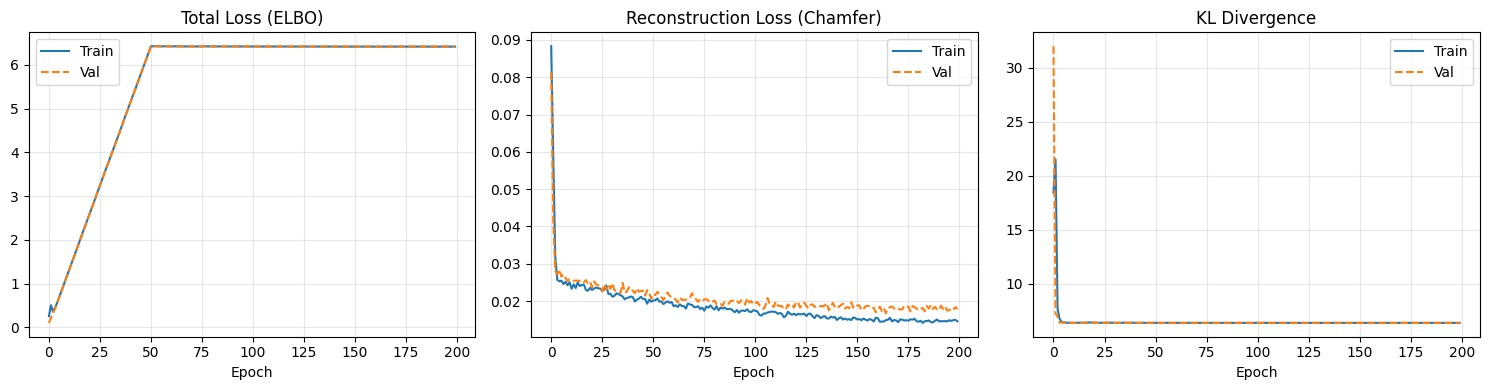

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (train_key, val_key), title in zip(
    axes,
    [("train_loss", "val_loss"), ("train_recon", "val_recon"), ("train_kl", "val_kl")],
    ["Total Loss (ELBO)", "Reconstruction Loss (Chamfer)", "KL Divergence"]
):
    ax.plot(history[train_key], label="Train", linewidth=1.5)
    ax.plot(history[val_key],   label="Val",   linewidth=1.5, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Inverse Design (Inference)

Given a desired property vector, sample `z ~ N(0, I)` and generate a novel point cloud.

Generated 3 point clouds, each of shape (1024, 3)


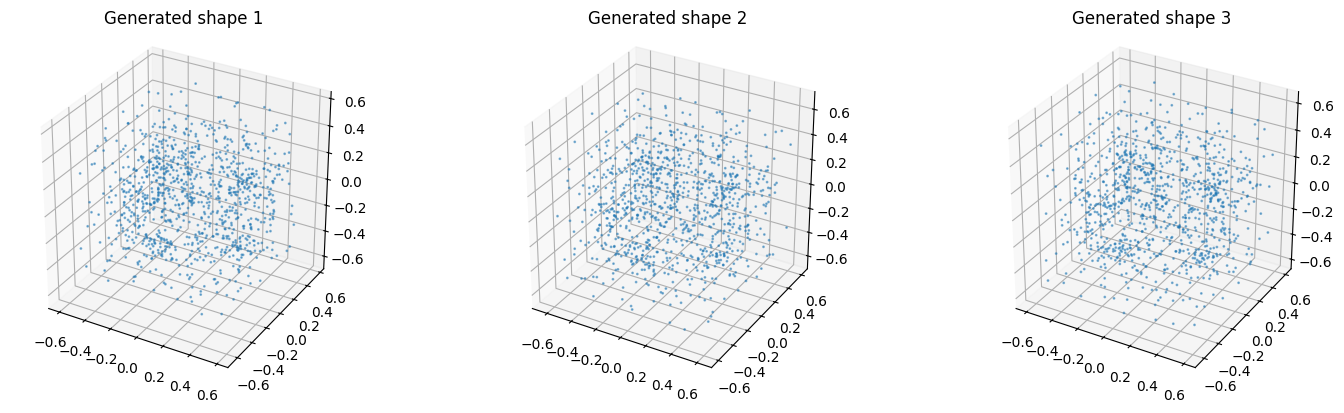

In [9]:
target_props = torch.tensor([0.5, 0.5], dtype=torch.float32).to(DEVICE)

N_GEN = 3
generated_pcs = model.generate(target_props, n_samples=N_GEN)
print(f"Generated {N_GEN} point clouds, each of shape {tuple(generated_pcs.shape[1:])}")

fig = plt.figure(figsize=(5 * N_GEN, 4))
for i in range(N_GEN):
    pc = generated_pcs[i].cpu().numpy()
    ax = fig.add_subplot(1, N_GEN, i + 1, projection='3d')
    ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], s=1, alpha=0.5)
    ax.set_title(f"Generated shape {i+1}")
    ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.savefig("generated_shapes.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Latent Space Visualisation (PCA)

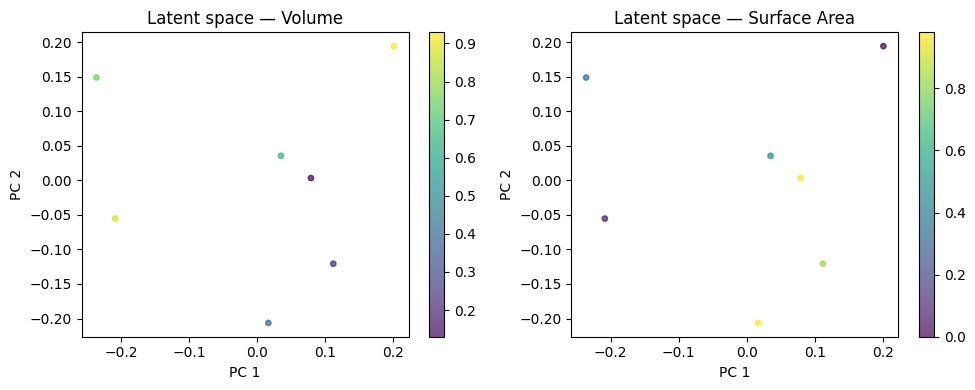

In [10]:
from sklearn.decomposition import PCA

model.eval()
all_mu, all_props = [], []

with torch.no_grad():
    for props, pcs in val_loader:
        mu, _ = model.encoder(props.to(DEVICE), pcs.to(DEVICE))
        all_mu.append(mu.cpu().numpy())
        all_props.append(props.numpy())

all_mu    = np.concatenate(all_mu)
all_props = np.concatenate(all_props)

mu_2d = PCA(n_components=2).fit_transform(all_mu)

property_names = ["Volume", "Surface Area"]

fig, axes = plt.subplots(1, PROP_DIM, figsize=(5 * PROP_DIM, 4))
if PROP_DIM == 1: axes = [axes]

for i, ax in enumerate(axes):
    sc = ax.scatter(mu_2d[:, 0], mu_2d[:, 1], c=all_props[:, i],
                    cmap="viridis", s=15, alpha=0.7)
    plt.colorbar(sc, ax=ax)
    ax.set_title(f"Latent space — {property_names[i]}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

plt.tight_layout()
plt.savefig("latent_space_pca.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Save & Load

In [11]:
CHECKPOINT = "cvae_checkpoint.pt"

torch.save({
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history":              history,
    "config": {
        "prop_dim":   PROP_DIM,
        "n_points":   N_POINTS,
        "point_dim":  POINT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "z_dim":      Z_DIM,
    }
}, CHECKPOINT)

print(f"Saved to {CHECKPOINT}")

ckpt  = torch.load(CHECKPOINT, map_location=DEVICE)
model = CVAE(**ckpt["config"]).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])

Saved to cvae_checkpoint.pt


<All keys matched successfully>